## Phase 0: Domain Knowledge & Data Dictionary
Understanding the medical context of each feature is crucial for accurate feature engineering and model interpretability.

* **Age:** Age of the patient , Increasing age is considered an indicator of an increased likelihood of developing heart disease.
* **Sex:** 1 = male; 0 = female.
* **CP (Chest Pain):** 4 types (Typical Angina, Atypical Angina (Not Clear Angina), Non-anginal Pain(Not heart pain), Asymptomatic (silent pain)).
* **Trestbps:** Resting blood pressure (Normal is ~120).
* **Chol:** Serum cholesterol (Above 240 mg/dl indicator for dangre).
* **FBS (Fasting Blood Sugar):** 1 if > 120 mg/dl (High); 0 otherwise (Normal)
* **RestECG:** Resting electrocardiographic results. 
    * 0 (Normal) → The heart is working normally
    * 1 (Abnormal) → There is a small issue with the heart signal
    * 2 (Serious issue) → The heart shows clear signs of stress or a bigger problem
* **thalach:** Maximum heart rate achieved during exercise; higher (within normal range) is generally better, while unusually low values may indicate a heart problem.
* **exang:** Exercise-induced chest pain; 0 is better (no pain), while 1 may indicate heart disease risk.
* **Oldpeak:** Drop in heart performance during exercise; higher values indicate higher risk.
* **slope:** ECG pattern during exercise; 1 (upsloping) is better, while 2 (flat) and 3 (downsloping) may indicate heart disease risk.
* **ca:** Number of major vessels with good blood flow (0–3); higher values are better, while lower values indicate possible artery blockage.
* **Thal:** Blood flow condition of the heart; shows whether blood supply is normal or reduced. 1= normal; 2 = fixed defect; 3 = reversable defect.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

data=pd.read_csv(r"D:\College\Semmester_6\IntelligentProgramming\Assignment_2\Heart Disease Detection Project\Data\RawData\heart.csv")
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1.0,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0.0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1.0,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1.0,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1.0,106,0,1.9,1,3,2,0


In [2]:
# EDA
print(data.shape)   # 1025 Samples , 14 Columns
print(data.info())  # Numerical Datasets
# We have to convert restecg to int from float

(1025, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1024 non-null   float64
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1023 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(2), int64(12)
memory usage: 112.2 KB
None


In [4]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1024.000000,1025.000000,1025.000000,1023.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529297,149.114146,0.336585,1.072043,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527931,23.005724,0.472772,1.176008,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
cols=['sex','cp','fbs','restecg','exang','slope','ca','thal','target']
for col in cols:
    print(data[col].value_counts())
# Thal Appear with zero value , This is an indicator of nothing , so we have Missing Values here    

sex
1    713
0    312
Name: count, dtype: int64
cp
0    497
2    284
1    167
3     77
Name: count, dtype: int64
fbs
0    872
1    153
Name: count, dtype: int64
restecg
1.0    512
0.0    497
2.0     15
Name: count, dtype: int64
exang
0    680
1    345
Name: count, dtype: int64
slope
1    482
2    469
0     74
Name: count, dtype: int64
ca
0    578
1    226
2    134
3     69
4     18
Name: count, dtype: int64
thal
2    544
3    410
1     64
0      7
Name: count, dtype: int64
target
1    526
0    499
Name: count, dtype: int64


In [6]:
print(data.isnull().sum()) # only 1 missing in restecg and 2 in oldpeak
print(data.duplicated().sum()) # 720 Duplicated row (We have to Drop these rows)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     1
thalach     0
exang       0
oldpeak     2
slope       0
ca          0
thal        0
target      0
dtype: int64
720


In [7]:
# Check Taret Balance : 
print(data['target'].value_counts(normalize=True)) # 1==>51% , 0==>49% Balanced Data 

target
1    0.513171
0    0.486829
Name: proportion, dtype: float64


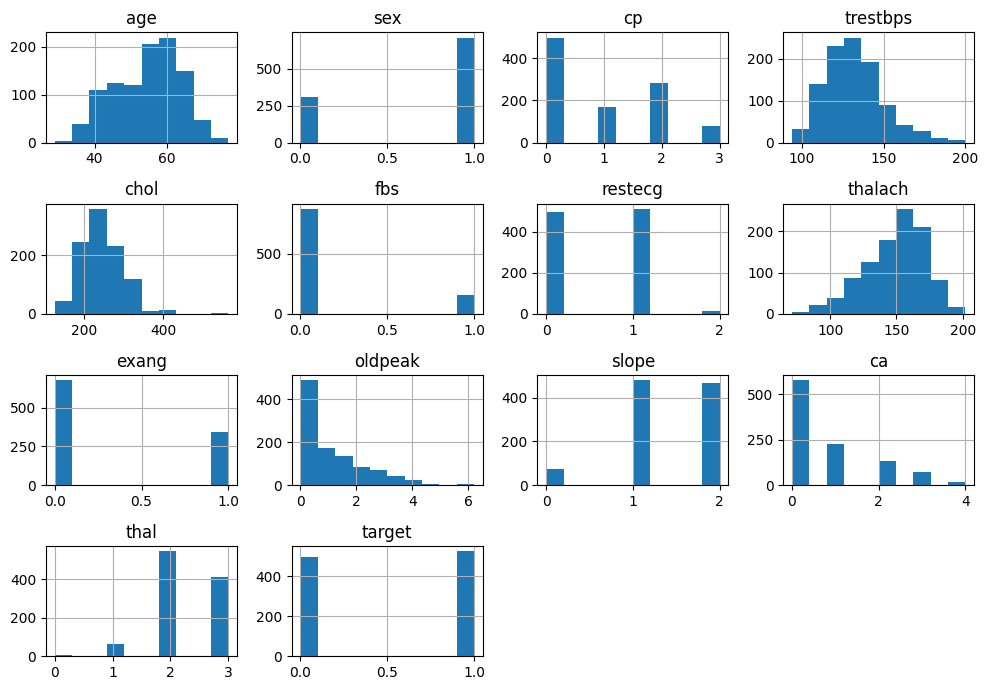

In [8]:
# Univariate Analysis:
data.hist(figsize=(10,7))
plt.tight_layout()
plt.title("Histograme For Showing Distributions")
plt.show()
# trestpbs and oldpeak have right skewness ,but thalach and age have left skeweness , we may use Transformations like sqrt or log to decrease outliers effects and make value more normally

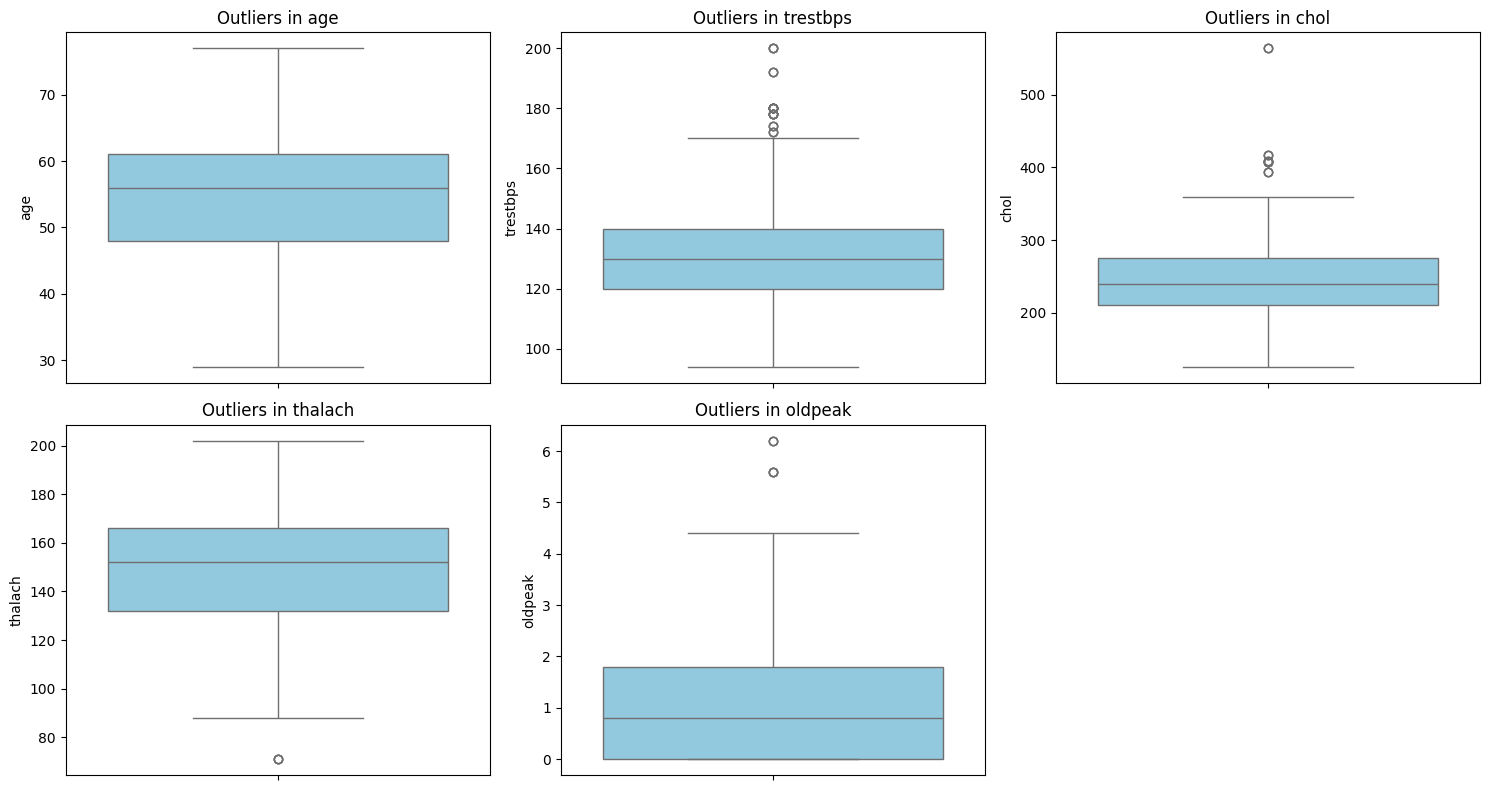

In [9]:
continuous_features=['age','trestbps','chol','thalach','oldpeak']
plt.figure(figsize=(15, 8))
for i, col in enumerate(continuous_features, 1): # No subplot start with 0 index
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[col], color='skyblue')
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()
# As we can see , ("trestbps" , "chol" , "oldpeak" , "thalach") ===> have an outliers 

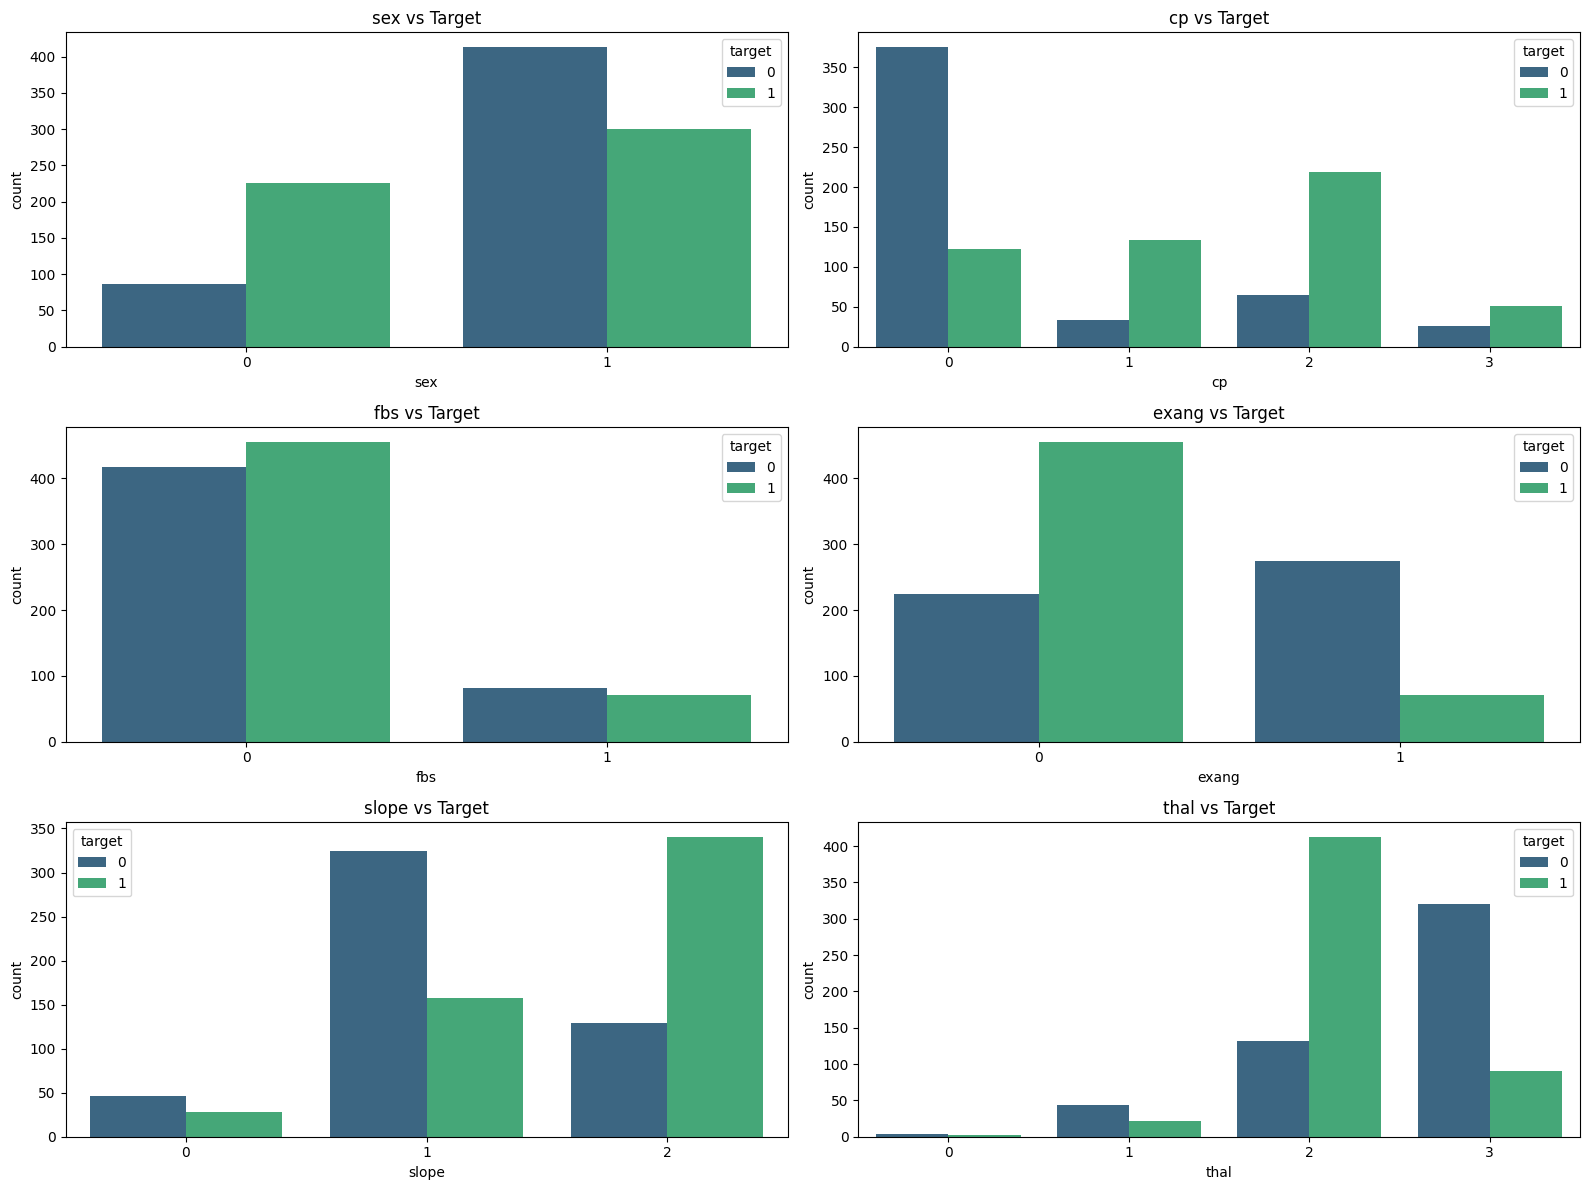

In [10]:
# Bivariate Analysis : For Categorical values
cat_features = ['sex', 'cp', 'fbs', 'exang', 'slope', 'thal']

plt.figure(figsize=(16, 12))
for i, col in enumerate(cat_features, 1):
    plt.subplot(3, 2, i)
    sns.countplot(x=col, hue='target', data=data, palette='viridis')
    plt.title(f'{col} vs Target')

plt.tight_layout()
plt.show()

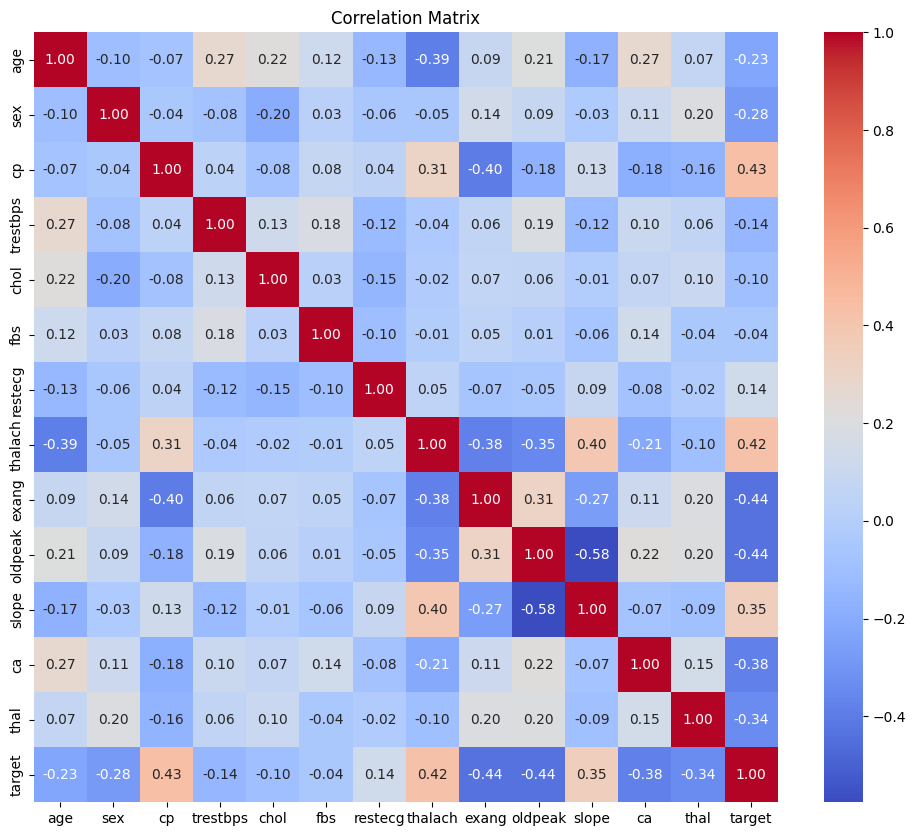

In [11]:
# MultiVariate Analysis : Heatmap 
plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()
# Feature With Feature : the highest value is -0.58 (slope , oldpeak) , Not sufficient for deletion 
# Feature With Target :
# Vary Small Corr :['fbs'] 0.04 it's a very small value , so fbs doesn't infuence on the target , we will drop this feature
# Important Features are : [ 'oldpeak' , 'cp' , 'exang' , 'thalach' , 'slope' , 'ca' , 'thal' ,'age' , 'sex']
# small correlation : ['chol' , 'trestbps' , 'restecg']

### Insight:

- cp has strong positive relationship with target
- exang , oldpeak have a strong negative relationship
- fbs shows no clear pattern → weak feature

In [12]:
# Detecting On Outliers Using IQR :
for col in data.columns:
    Q1=data[col].quantile(0.25)
    Q3=data[col].quantile(0.75)
    IQR=Q3-Q1
    lower_boundry=Q1-(IQR*1.5)
    Upper_boundry=Q3+(IQR*1.5)
    outliers=data[(data[col]>Upper_boundry) | (data[col]<lower_boundry) ]
    print(f"Column {col}: Found {len(outliers)} outliers. Max value: {data[col].max()}")
# Columns with an outliers are : ["trestbps" , "chol" , "oldpeak" , "thalach" , "fbs" ,"ca" ,"thal" ] 

Column age: Found 0 outliers. Max value: 77
Column sex: Found 0 outliers. Max value: 1
Column cp: Found 0 outliers. Max value: 3
Column trestbps: Found 30 outliers. Max value: 200
Column chol: Found 16 outliers. Max value: 564
Column fbs: Found 153 outliers. Max value: 1
Column restecg: Found 0 outliers. Max value: 2.0
Column thalach: Found 4 outliers. Max value: 202
Column exang: Found 0 outliers. Max value: 1
Column oldpeak: Found 7 outliers. Max value: 6.2
Column slope: Found 0 outliers. Max value: 2
Column ca: Found 87 outliers. Max value: 4
Column thal: Found 7 outliers. Max value: 3
Column target: Found 0 outliers. Max value: 1
